# MOMA

## 1a. Process Optimization output

This code creates a reference set from the different seeds

NOTE: For MMBorg archives, run the script to convert it to the format recognized by older code with ema-workbench.

In [1]:
!python justice/util/borg_archive_processor.py \
    --archive /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/mm_intermediate_5.zip \
    --base-name MOMA_200000_ref2 \
    --step 10000 \
    --island-offset 0

!python justice/util/borg_archive_processor.py \
    --archive /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/mm_intermediate_4.zip \
    --base-name MOMA_200000_ref2 \
    --step 10000 \
    --island-offset 5


Archive        : /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/mm_intermediate_5.zip
Islands found  : 5
Island offset  : 0  → indices 0..4
Step filter    : every 10000
Output dir     : /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION

[OK] /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/MOMA_200000_ref2_0.tar.gz  (source island: mm_0)
[OK] /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/MOMA_200000_ref2_1.tar.gz  (source island: mm_1)
[OK] /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/MOMA_200000_ref2_2.tar.gz  (source island: mm_2)
[OK] /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/MOMA_200000_ref2_3.tar.gz  (source island: mm_3)
[OK] /Users/palokbiswas/Desktop/polloc

## 1b. Create reference set

In [6]:
# ── Section 1b: Compute Reference Set + Epsilon Filtering ────────────────────
from solvers.convergence.pareto import eps_sort
import numpy as np
import pandas as pd
import zipfile
import tarfile
import io
import os
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────────────────────
base_path  = "data/temporary/MOMA_DATA/200k"
joint_path = f"{base_path}/JOINT_OPTIMIZATION"

zip_5_islands = f"{joint_path}/mm_intermediate_5.zip"
zip_4_islands = f"{joint_path}/mm_intermediate_4.zip"

list_of_objectives = [
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
]

maximize_cols = [1, 2, 3, 4, 5]

# Two filtering levels:
#   fine  → large reference set, used for hypervolume calculation
#   coarse → small policy set, used for simulation & analysis
epsilon_configs = {
    "fine":   {"epsilons": [0.001, 0.001, 0.001, 0.001, 0.001, 0.001],
               "filename": "MOMA_reference_set_fine.csv"},
    "coarse": {"epsilons": [50, 50, 50, 50, 50, 0.1],
               "filename": "COMBINED_MOMA_epsilon_nondominated_set.csv"},
}

# ── HELPER: extract 200000.csv from nested tar.gz inside a zip ────────────────
def extract_final_csv_from_zip(zip_path: str) -> pd.DataFrame:
    """
    Opens zip_path, finds the nested MOMADPS_200000_*.tar.gz,
    extracts tmp/200000.csv from it, returns as DataFrame.
    """
    dfs = []
    with zipfile.ZipFile(zip_path, "r") as outer_zip:
        tar_names = [n for n in outer_zip.namelist() if n.endswith(".tar.gz")]
        print(f"      Found {len(tar_names)} tar.gz files in {os.path.basename(zip_path)}")

        for tar_name in tar_names:
            with outer_zip.open(tar_name) as tar_bytes:
                with tarfile.open(fileobj=io.BytesIO(tar_bytes.read()), mode="r:gz") as tar:
                    csv_members = [m for m in tar.getmembers()
                                   if m.name.endswith("200000.csv")]
                    if not csv_members:
                        print(f"      [WARN] No 200000.csv found in {tar_name}, skipping.")
                        continue
                    f = tar.extractfile(csv_members[0])
                    df = pd.read_csv(f)
                    dfs.append(df)
                    print(f"      Loaded {len(df)} rows from {tar_name} → {csv_members[0].name}")

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ── STEP 1: Extract and concatenate 200000.csv from both zips ────────────────
print("[1/3] Extracting final archives from both zip files...")

print(f"\n  Processing: {zip_5_islands}")
df_5 = extract_final_csv_from_zip(zip_5_islands)

print(f"\n  Processing: {zip_4_islands}")
df_4 = extract_final_csv_from_zip(zip_4_islands)

df_combined = pd.concat([df_5, df_4], ignore_index=True)
combined_path = f"{joint_path}/MOMA_combined_reference_set_9_islands.csv"
df_combined.to_csv(combined_path, index=False)

print(f"\n  Rows from 5-island run : {len(df_5)}")
print(f"  Rows from 4-island run : {len(df_4)}")
print(f"  Total combined rows    : {len(df_combined)}")
print(f"  Saved to               : {combined_path}\n")

# ── STEP 2: Filter at both epsilon levels ─────────────────────────────────────
print("[2/3] Applying epsilon-nondominated filtering...")

table = df_combined.reset_index()[["index"] + list_of_objectives].to_numpy()

for level, cfg in epsilon_configs.items():
    tagalongs = eps_sort(
        table,
        objectives=[1, 2, 3, 4, 5, 6],
        epsilons=cfg["epsilons"],
        maximize=maximize_cols,
    )
    tagalongs       = np.array(tagalongs)
    tagalongs[:, 0] = tagalongs[:, 0].astype(int)
    pareto_idx      = np.unique(tagalongs[:, 0])
    filtered_df     = df_combined.loc[pareto_idx].copy()

    out_file = f"{joint_path}/{cfg['filename']}"
    filtered_df.to_csv(out_file, index=False)
    print(f"  [{level:6s}]  epsilons: {cfg['epsilons']}"
          f"  →  {len(filtered_df):4d} policies  →  {out_file}")

print("\n[3/3] Summary of outputs:")
print(f"  Combined raw set  : {combined_path}")
for level, cfg in epsilon_configs.items():
    print(f"  {level:6s} filtered : {joint_path}/{cfg['filename']}")


[1/3] Extracting final archives from both zip files...

  Processing: data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/mm_intermediate_5.zip
      Found 1 tar.gz files in mm_intermediate_5.zip
      Loaded 264 rows from MOMADPS_200000_66.tar.gz → tmp/200000.csv

  Processing: data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/mm_intermediate_4.zip
      Found 1 tar.gz files in mm_intermediate_4.zip
      Loaded 1016 rows from MOMADPS_200000_555.tar.gz → tmp/200000.csv

  Rows from 5-island run : 264
  Rows from 4-island run : 1016
  Total combined rows    : 1280
  Saved to               : data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/MOMA_combined_reference_set_9_islands.csv

[2/3] Applying epsilon-nondominated filtering...
  [fine  ]  epsilons: [0.001, 0.001, 0.001, 0.001, 0.001, 0.001]  →    35 policies  →  data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/MOMA_reference_set_fine.csv
  [coarse]  epsilons: [50, 50, 50, 50, 50, 0.1]  →     5 policies  →  data/temporary/MOMA_DATA/200k/J

## 1c. Testing the hypervolume

In [9]:
# ── Section 1c: Hypervolume Calculation & Plot ────────────────────────────────
from solvers.convergence.hypervolume import calculate_hypervolume_from_archives
from justice.util.visualizer import plot_hypervolume
import multiprocessing
import os

# ── CONFIG ────────────────────────────────────────────────────────────────────
base_name  = "MOMA_200000_ref2"
hv_dir     = f"{joint_path}/hypervolumes"
plots_dir  = f"{base_path}/plots"
ref_file   = "MOMA_reference_set_fine.csv"   # fine-grained joint ref set for all islands
os.makedirs(hv_dir,    exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# ── STEP 1: Compute Hypervolume per island ────────────────────────────────────
print(f"[1/2] Computing hypervolumes for all 9 islands...")
print(f"      Reference set : {ref_file}\n")
hv_files = {}

list_of_objectives = [
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
]

with multiprocessing.Pool() as pool:
    for island_idx in range(9):
        filename = f"{base_name}_{island_idx}.tar.gz"
        print(f"      Island {island_idx}: {filename}")

        calculate_hypervolume_from_archives(
            list_of_objectives=list_of_objectives,
            direction_of_optimization=["max", "max", "max", "max", "max", "min"],
            input_data_path=joint_path,
            file_name=filename,
            output_data_path=hv_dir,
            saving=True,
            global_reference_set=True,
            global_reference_set_path=joint_path,
            global_reference_set_file=ref_file,
            pool=pool,
        )
        hv_files[island_idx] = f"hypervolumes/{base_name}_{island_idx}_hv.csv"

print(f"\n      Hypervolume files saved to: {hv_dir}")

# ── STEP 2: Plot Hypervolume ──────────────────────────────────────────────────
print("\n[2/2] Plotting hypervolume convergence...")

input_data_path_list = {
    "MOMA 200k (all 9 seeds)": [hv_files[i] for i in range(9)],
}

fig = plot_hypervolume(
    path_to_data=joint_path,
    path_to_output=plots_dir,
    input_data=input_data_path_list,
    yaxis_upper_limit=0.8,
    width=1000,
    height=800,
    fontsize=20,
    saving=True,
)

fig.show()
print(f"      Plot saved to: {plots_dir}")


[1/2] Computing hypervolumes for all 9 islands...
      Reference set : MOMA_reference_set_fine.csv

      Island 0: MOMA_200000_ref2_0.tar.gz
Loading archives for MOMA_200000_ref2_0.tar.gz
Archives loaded
list_of_archives:  (3182, 6)
reference_set (35, 6)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  MOMA_200000_ref2_0.tar.gz
Time taken for Hypervolume Calculation: 3.114 seconds
data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/hypervolumes/MOMA_200000_ref2_0_hv.csv
      Island 1: MOMA_200000_ref2_1.tar.gz
Loading archives for MOMA_200000_ref2_1.tar.gz
Archives loaded
list_of_archives:  (2552, 6)
reference_set (35, 6)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000

      Plot saved to: data/temporary/MOMA_DATA/200k/plots


# 2. Pareto Nash

In [ ]:
# ── Section 2: Pareto-Nash Filtering ─────────────────────────────────────────
import pandas as pd
import os
from justice.util.pareto_nash_search import is_pareto_dominated
# ── CONFIG ────────────────────────────────────────────────────────────────────
base_path = "data/temporary/MOMA_DATA/200k"
processed_path = f"{base_path}/PROCESSED_DATA"
joint_path = f"{base_path}/JOINT_OPTIMIZATION"
os.makedirs(processed_path, exist_ok=True)

input_file  = f"{joint_path}/COMBINED_MOMA_epsilon_nondominated_set.csv"
output_file = f"{processed_path}/pareto_nash_profiles.csv"

agent_objectives = {
    "agent_1": ["macro_welfare_R5ASIA", "fraction_above_threshold"],
    "agent_2": ["macro_welfare_R5LAM",  "fraction_above_threshold"],
    "agent_3": ["macro_welfare_R5MAF",  "fraction_above_threshold"],
    "agent_4": ["macro_welfare_R5OECD", "fraction_above_threshold"],
    "agent_5": ["macro_welfare_R5REF",  "fraction_above_threshold"],
}
minimize_objectives = ["fraction_above_threshold"]

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(input_file).reset_index(drop=True)
print(f"Loaded {len(df)} candidate solutions from: {input_file}\n")


# ── PARETO-NASH FILTERING ─────────────────────────────────────────────────────
print("Checking Pareto-Nash conditions for each solution...\n")
pareto_nash_indices = []

for solution_idx in df.index:
    is_pareto_nash = all(
        not is_pareto_dominated(
            solution_idx, agent_name, df,
            agent_objectives, minimize_objectives,
        )
        for agent_name in agent_objectives
    )

    if is_pareto_nash:
        pareto_nash_indices.append(solution_idx)
        print(f"  Solution {solution_idx:>3} is PARETO-NASH ✓")

# ── RESULTS ───────────────────────────────────────────────────────────────────
pareto_nash_df = df.loc[pareto_nash_indices].copy().reset_index(drop=True)

print(f"\nFound {len(pareto_nash_df)} Pareto-Nash solutions out of {len(df)} candidates.")
print(f"\nObjective values for Pareto-Nash set:")
print(pareto_nash_df[list(agent_objectives["agent_1"][:-1]) +
                     [f"macro_welfare_{r}" for r in ["R5LAM","R5MAF","R5OECD","R5REF"]] +
                     ["fraction_above_threshold"]].to_string(index=True))

# pareto_nash_df.to_csv(output_file, index=True, index_label="profile_index")
# print(f"\nSaved to: {output_file}")


Loaded 5 candidate solutions from: data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/COMBINED_MOMA_epsilon_nondominated_set.csv

Checking Pareto-Nash conditions for each solution...

  Solution   4 is PARETO-NASH ✓

Found 1 Pareto-Nash solutions out of 5 candidates.

Objective values for Pareto-Nash set:
   macro_welfare_R5ASIA  macro_welfare_R5LAM  macro_welfare_R5MAF  macro_welfare_R5OECD  macro_welfare_R5REF  fraction_above_threshold
0             1707.0187          3027.130867          2137.421176             3372.8681          2145.106776                      0.42


### Section 2b: Payoff Table Generation & Pareto-Nash Profile Extraction

This section computes the **Pareto-Nash equilibrium profiles** for the 5-agent climate policy game. It proceeds in three steps:

**Step 1 — Benchmark.** A quick sequential timing test runs a small sample of profiles (default: 10) to estimate how long the full computation will take. This step is optional and can be commented out after the first run.

**Step 2 — Payoff table construction.** All 5⁵ = 3,125 possible action combinations across the 5 macro-regional agents are enumerated and simulated through the full JUSTICE model. Each simulation runs the complete climate-economy time loop across all FaIR ensemble members, computing regional welfare and the fraction of ensemble members exceeding 2°C warming by the target year. Simulations are distributed across available CPU cores using multiprocessing to reduce wall time. Results are written incrementally to `payoff_table_5x5x5x5x5.csv` in the processed data folder.

> ⚠️ **This is the most computationally expensive step in the analysis.** Expect **30–90 minutes** of wall time depending on hardware and the number of workers. A skip guard prevents re-running if the output file already exists — do not delete this file unless the underlying policies or model configuration have changed.

**Step 3 — Pareto-Nash extraction.** The payoff table is filtered to retain only **Pareto-Nash equilibrium profiles** — action combinations where no agent can unilaterally switch to a strategy that improves their own welfare *and* the climate outcome simultaneously. For each agent, best responses are identified by fixing all other agents' actions and finding the Pareto-nondominated strategies (trading off welfare against fraction above 2°C). A profile is classified as Pareto-Nash only if every agent is simultaneously on their own Pareto frontier. The resulting profiles are saved to `pareto_nash_profiles.csv` and passed to Section 3 for full simulation.

In [ ]:
# ── Section 2: Generate Payoff Table & Extract Pareto-Nash Profiles ───────────
from justice.util.pareto_nash_search import (
    benchmark_profiles,
    run_5pow5_payoff_table,
    pareto_nash_set,
)
import multiprocessing as mp
import os

# ── CONFIG ────────────────────────────────────────────────────────────────────
policy_csv_path = f"{joint_path}/COMBINED_MOMA_epsilon_nondominated_set.csv"
config_path     = "analysis/momadps_config.json"
payoff_csv_path = f"{processed_path}/payoff_table_5x5x5x5x5.csv"
nash_out_path   = f"{processed_path}/pareto_nash_profiles.csv"
n_workers       = max(1, mp.cpu_count() - 1)   # tune down if memory is tight
chunksize       = 8

# ── STEP 1: Benchmark (optional — comment out after first run) ────────────────
print("[0/3] Benchmarking to estimate runtime...")
benchmark_profiles(
    policy_csv_path=policy_csv_path,
    config_path=config_path,
    scenario=2,
    mapping_base_path="data/input",
    n_samples=10,
    seed=0,
)

# ── STEP 2: Run full 5^5 payoff table ────────────────────────────────────────
# ⚠ This is the longest step — expect 30–90 min depending on n_workers and hardware
# Skip if payoff_csv_path already exists

if os.path.exists(payoff_csv_path):
    print(f"\n[1/3] Payoff table already exists, skipping: {payoff_csv_path}")
else:
    print(f"\n[1/3] Running 5^5 = 3125 profiles with {n_workers} workers...")
    run_5pow5_payoff_table(
        policy_csv_path=policy_csv_path,
        config_path=config_path,
        out_csv_path=payoff_csv_path,
        scenario=2,
        mapping_base_path="data/input",
        n_workers=n_workers,
        chunksize=chunksize,
    )
    print(f"      Saved to: {payoff_csv_path}")

# ── STEP 3: Extract Pareto-Nash profiles ──────────────────────────────────────
print(f"\n[2/3] Extracting Pareto-Nash profiles from payoff table...")
pn_df = pareto_nash_set(
    payoff_csv_path=payoff_csv_path,
    minimize_fraction=True,
    fraction_col="fraction_above_threshold",
    welfare_prefix="welfare_",
    action_prefix="a",
    n_agents=None,   # inferred from columns
)

pn_df.to_csv(nash_out_path, index=False)

print(f"      Found {len(pn_df)} Pareto-Nash profiles out of 3125.")
print(f"      Saved to: {nash_out_path}")
print(f"\n      Preview:")
cols = [c for c in pn_df.columns if c.startswith("a") or
        c.startswith("welfare_")] + ["fraction_above_threshold"]
print(pn_df[cols].to_string(index=True))


[0/3] Benchmarking to estimate runtime...
Benchmark: 10 samples in 4.787s
Time/profile: 0.4787s
Estimated time for 5^5=3125 profiles: 24.93 minutes

[1/3] Running 5^5 = 3125 profiles with 9 workers...
100/3125 done | 5.65 проф/s | ETA 8.9 min
200/3125 done | 7.38 проф/s | ETA 6.6 min
300/3125 done | 7.35 проф/s | ETA 6.4 min
400/3125 done | 8.25 проф/s | ETA 5.5 min
500/3125 done | 8.68 проф/s | ETA 5.0 min
600/3125 done | 8.74 проф/s | ETA 4.8 min
700/3125 done | 9.10 проф/s | ETA 4.4 min
800/3125 done | 9.32 проф/s | ETA 4.2 min
900/3125 done | 9.33 проф/s | ETA 4.0 min
1000/3125 done | 9.56 проф/s | ETA 3.7 min
1100/3125 done | 9.68 проф/s | ETA 3.5 min
1200/3125 done | 9.73 проф/s | ETA 3.3 min
1300/3125 done | 9.93 проф/s | ETA 3.1 min
1400/3125 done | 9.81 проф/s | ETA 2.9 min
1500/3125 done | 9.85 проф/s | ETA 2.8 min
1600/3125 done | 9.84 проф/s | ETA 2.6 min
1700/3125 done | 9.83 проф/s | ETA 2.4 min
1800/3125 done | 9.93 проф/s | ETA 2.2 min
1900/3125 done | 9.86 проф/s | ETA

### 2b Selecting Pareto-Nash profiles for simulation

In [2]:
# ── Section 2b: Select Focal Pareto-Nash Profiles ────────────────────────────
import pandas as pd
import numpy as np

base_path  = "data/temporary/MOMA_DATA/200k"
processed_path = f"{base_path}/PROCESSED_DATA"
nash_out_path   = f"{processed_path}/pareto_nash_profiles.csv"

# ── Load Pareto-Nash set ──────────────────────────────────────────────────────
pn_df = pd.read_csv(nash_out_path)
action_cols  = [c for c in pn_df.columns if c.startswith("a") and c[1:].isdigit()]
welfare_cols = [c for c in pn_df.columns if c.startswith("welfare_")]
n_agents     = len(action_cols)

# ── PROFILE 1: Joint optimization candidate ───────────────────────────────────
# In the joint Pareto front, all agents share the same policy row (uniform action).
# We identify this as the profile where a0 == a1 == ... == a4.
joint_mask     = pn_df[action_cols].nunique(axis=1) == 1
joint_profiles = pn_df[joint_mask]

if len(joint_profiles) == 0:
    raise RuntimeError(
        "No uniform-action profile found in Pareto-Nash set. "
        "Check if the joint optimization candidate was correctly included."
    )
elif len(joint_profiles) > 1:
    # If multiple uniform-action profiles exist, pick the one with
    # lowest fraction_above_threshold (most balanced mitigation)
    joint_profile = joint_profiles.loc[
        joint_profiles["fraction_above_threshold"].idxmin()
    ]
    print(f"  Note: {len(joint_profiles)} uniform-action profiles found; "
          f"selected the one with lowest fraction_above_threshold.")
else:
    joint_profile = joint_profiles.iloc[0]

joint_idx = int(joint_profile.name)

# ── PROFILE 2: Best temperature outcome ───────────────────────────────────────
best_temp_idx  = int(pn_df["fraction_above_threshold"].idxmin())
best_temp_profile = pn_df.loc[best_temp_idx]

# ── PROFILE 3: Worst temperature outcome ──────────────────────────────────────
worst_temp_idx = int(pn_df["fraction_above_threshold"].idxmax())
worst_temp_profile = pn_df.loc[worst_temp_idx]

# ── Summary ───────────────────────────────────────────────────────────────────
selected_indices = [joint_idx, best_temp_idx, worst_temp_idx]
labels = {
    joint_idx:      "Joint optimization candidate (balanced)",
    best_temp_idx:  "Best temperature outcome",
    worst_temp_idx: "Worst temperature outcome",
}

print(f"\nSelected Pareto-Nash profiles ({len(selected_indices)} of {len(pn_df)}):\n")
display_cols = action_cols + welfare_cols + ["fraction_above_threshold"]

for idx, label in labels.items():
    row = pn_df.loc[idx]
    actions  = row[action_cols].tolist()
    welfares = [f"{row[c]:.4f}" for c in welfare_cols]
    frac     = row["fraction_above_threshold"]
    print(f"  [{idx:>3}]  {label}")
    print(f"         Actions  : {actions}")
    print(f"         Welfares : {welfares}")
    print(f"         Frac>2°C : {frac:.4f}\n")

# ── Save selection metadata ───────────────────────────────────────────────────
selection_meta = {
    "joint_candidate_index":  joint_idx,
    "best_temperature_index": best_temp_idx,
    "worst_temperature_index": worst_temp_idx,
}

import json
meta_path = f"{processed_path}/focal_profile_indices.json"
with open(meta_path, "w") as f:
    json.dump(selection_meta, f, indent=2)

print(f"Focal profile indices saved to: {meta_path}")



Selected Pareto-Nash profiles (3 of 88):

  [ 86]  Joint optimization candidate (balanced)
         Actions  : [4, 4, 4, 4, 4]
         Welfares : ['1707.0187', '3027.1309', '2137.4212', '3372.8681', '2145.1068']
         Frac>2°C : 0.4200

  [  9]  Best temperature outcome
         Actions  : [0, 1, 4, 3, 2]
         Welfares : ['1710.8636', '3032.3700', '2159.9756', '3368.8039', '2119.1604']
         Frac>2°C : 0.3800

  [ 52]  Worst temperature outcome
         Actions  : [3, 3, 3, 2, 0]
         Welfares : ['1682.5163', '3001.4970', '2132.4574', '3442.0717', '2182.3716']
         Frac>2°C : 0.6000

Focal profile indices saved to: data/temporary/MOMA_DATA/200k/PROCESSED_DATA/focal_profile_indices.json


## 3. Simulating Pareto-Nash policies


> ⚠️ **This is also computationally expensive and will require sufficient memory.** 


In [2]:
# ── Section 3: Simulate Focal Pareto-Nash Profiles ───────────────────────────
import json
from justice.util.pareto_nash_simulate import simulate_nash_profiles_by_row_index

with open(f"{processed_path}/focal_profile_indices.json") as f:
    focal = json.load(f)

selected_profile_indices = list(focal.values())   # [joint, best_temp, worst_temp]
print(f"Simulating profiles: {selected_profile_indices}")

simulate_nash_profiles_by_row_index(
    nash_profiles_csv        = f"{processed_path}/pareto_nash_profiles.csv",
    policy_5row_csv          = f"{joint_path}/COMBINED_MOMA_epsilon_nondominated_set.csv",
    config_path              = "analysis/momadps_config.json",
    out_dir                  = f"{processed_path}/simulations",
    selected_profile_indices = selected_profile_indices,
    scenario                 = 2,
    mapping_base_path        = "data/input",
)


Simulating profiles: [86, 9, 52]
Nash profiles    : data/temporary/MOMA_DATA/200k/PROCESSED_DATA/pareto_nash_profiles.csv  (88 total)
Policy CSV       : data/temporary/MOMA_DATA/200k/JOINT_OPTIMIZATION/COMBINED_MOMA_epsilon_nondominated_set.csv
Profiles to run  : [86, 9, 52]
Output dir       : data/temporary/MOMA_DATA/200k/PROCESSED_DATA/simulations
⚠ This may take several minutes per profile.

  Profile  86 | actions: (4, 4, 4, 4, 4) ... done  |  frac_above_2C: 0.420
  Profile   9 | actions: (0, 1, 4, 3, 2) ... done  |  frac_above_2C: 0.380
  Profile  52 | actions: (3, 3, 3, 2, 0) ... done  |  frac_above_2C: 0.600

All done. Files saved to: data/temporary/MOMA_DATA/200k/PROCESSED_DATA/simulations


## 4. Single Agent Decentralized Optimization

In [1]:
# ── Section 4a: Extract Single-Agent Borg Archives ───────────────────────────
# 4 islands per agent (5-island runs still in progress — re-run this cell when ready)

import os

base_path  = "data/temporary/MOMA_DATA/200k"
single_agent_path = f"{base_path}/SINGLE_AGENT_TESTS"   # adjust if different
policies  = [9, 52, 86]
n_agents  = 5

for policy_idx in policies:
    for agent_idx in range(n_agents):
        archive = (
            f"{single_agent_path}/policy_{policy_idx}/"
            f"mm_intermediate_agent_{agent_idx}.zip"
        )
        base_name = f"SINGLE_AGENT_policy{policy_idx}_agent{agent_idx}"

        if not os.path.exists(archive):
            print(f"  [SKIP] Not found: {archive}")
            continue

        print(f"\n  Extracting policy={policy_idx}, agent={agent_idx}...")
        !python justice/util/borg_archive_processor.py \
            --archive "{archive}" \
            --base-name "{base_name}" \
            --step 10000 \
            --island-offset 0



  Extracting policy=9, agent=0...
Archive        : data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/mm_intermediate_agent_0.zip
Islands found  : 4
Island offset  : 0  → indices 0..3
Step filter    : every 10000
Output dir     : data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9

[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SINGLE_AGENT_policy9_agent0_0.tar.gz  (source island: mm_0)
[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SINGLE_AGENT_policy9_agent0_1.tar.gz  (source island: mm_1)
[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SINGLE_AGENT_policy9_agent0_2.tar.gz  (source island: mm_2)
[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SINGLE_AGENT_policy9_agent0_3.tar.gz  (source island: mm_3)

Done.

  Extracting policy=9, agent=1...
Archive        : data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/mm_intermediate_agent_1.zip
Islands found  : 4
Island offset  : 0  → indices 0..3
Step filter 

### 4b. Extract and build reference set for single agents

In [ ]:
# ── Section 4b: Extract & Build Per-Agent Reference Sets ─────────────────────
from solvers.convergence.pareto import eps_sort
import numpy as np
import pandas as pd

import os
import warnings
from justice.util.pareto_nash_search import extract_final_csv_from_zip
warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────────────────────
single_agent_path = f"{base_path}/SINGLE_AGENT_TESTS"

policies      = [9, 52, 86]
n_agents      = 5        # zip files: mm_intermediate_agent_0.zip .. agent_4.zip
fine_epsilons = [0.001, 0.001]




def infer_welfare_col(df: pd.DataFrame) -> str:
    welfare_cols = [c for c in df.columns if c.startswith("macro_welfare_")]
    if len(welfare_cols) != 1:
        raise ValueError(f"Expected exactly 1 macro_welfare_* column, found: {welfare_cols}")
    return welfare_cols[0]


# ── MAIN LOOP: policy × agent ─────────────────────────────────────────────────
print("Building per-agent reference sets...\n")
print(f"{'Policy':>8}  {'Agent':>5}  {'Welfare col':<25}  {'Raw rows':>9}  {'Ref set':>8}")
print("─" * 80)

for policy_idx in policies:
    policy_dir = f"{single_agent_path}/policy_{policy_idx}"
    out_dir    = f"{policy_dir}/reference_sets"
    os.makedirs(out_dir, exist_ok=True)

    for agent_idx in range(n_agents):     # 0-indexed: 0..4
        archive  = f"{policy_dir}/mm_intermediate_agent_{agent_idx}.zip"
        out_path = f"{out_dir}/reference_set_agent_{agent_idx}.csv"

        if not os.path.exists(archive):
            print(f"  policy_{policy_idx} / agent_{agent_idx}: [SKIP] archive not found")
            continue

        # ── Extract & concatenate all seeds ──────────────────────────────────
        df_raw = extract_final_csv_from_zip(archive)
        if df_raw.empty:
            print(f"  policy_{policy_idx} / agent_{agent_idx}: [SKIP] no data extracted")
            continue

        # ── Infer welfare column from CSV ─────────────────────────────────────
        welfare_col = infer_welfare_col(df_raw)

        # ── Epsilon-nondominated filtering ────────────────────────────────────
        table = df_raw.reset_index()[
            ["index", welfare_col, "fraction_above_threshold"]
        ].to_numpy()

        tagalongs  = eps_sort(
            table,
            objectives=[1, 2],      # ← was [1,2,3] — only 2 objectives here
            epsilons=fine_epsilons,
            maximize=[1],           # welfare → maximize; fraction → minimize
        )
        tagalongs  = np.array(tagalongs)
        pareto_idx = np.unique(tagalongs[:, 0].astype(int))
        ref_df     = df_raw.loc[pareto_idx].copy()


        ref_df.to_csv(out_path, index=False)
        print(f"  {policy_idx:>8}  {agent_idx:>5}  {welfare_col:<25}  "
              f"{len(df_raw):>9}  {len(ref_df):>8}")

print("\nDone.")


Building per-agent reference sets...

  Policy  Agent  Welfare col                 Raw rows   Ref set
────────────────────────────────────────────────────────────────────────────────
        Found 1 tar.gz in mm_intermediate_agent_0.zip
        Loaded     25 rows ← SingleAgent_0_200000_4444.tar.gz
         9      0  macro_welfare_R5ASIA              25         1
        Found 1 tar.gz in mm_intermediate_agent_1.zip
        Loaded      2 rows ← SingleAgent_1_200000_4444.tar.gz
         9      1  macro_welfare_R5LAM                2         1
        Found 1 tar.gz in mm_intermediate_agent_2.zip
        Loaded     10 rows ← SingleAgent_2_200000_4444.tar.gz
         9      2  macro_welfare_R5MAF               10         1
        Found 1 tar.gz in mm_intermediate_agent_3.zip
        Loaded      1 rows ← SingleAgent_3_200000_4444.tar.gz
         9      3  macro_welfare_R5OECD               1         1
        Found 1 tar.gz in mm_intermediate_agent_4.zip
        Loaded      1 rows ← Single

### 4c. Check if Single-Agent Optimization Dominates Joint Solution

In [7]:
# ── Section 4c: Check if Single-Agent Optimization Dominates Joint Solution ───
import pandas as pd
import numpy as np
import os
from justice.util.pareto_nash_search import is_pareto_dominated

# ── CONFIG ────────────────────────────────────────────────────────────────────
focal_policies      = [9, 52, 86]
n_agents            = 5   # 0-indexed: 0..4
minimize_objectives = {"fraction_above_threshold"}

base_path  = "data/temporary/MOMA_DATA/200k"
processed_path = f"{base_path}/PROCESSED_DATA"
nash_out_path   = f"{processed_path}/pareto_nash_profiles.csv"
single_agent_path = f"{base_path}/SINGLE_AGENT_TESTS"

# ── LOAD Pareto-Nash profiles ─────────────────────────────────────────────────
pn_df = pd.read_csv(nash_out_path)

print("=" * 72)
print("DOMINATION CHECK: Single-Agent Opt vs. Joint Opt (Pareto-Nash profile)")
print("=" * 72)

for policy_idx in focal_policies:

    if policy_idx not in pn_df.index:
        print(f"\n[WARN] Policy index {policy_idx} not found in pareto_nash_profiles.csv")
        continue

    joint_row  = pn_df.loc[policy_idx]
    joint_frac = float(joint_row["fraction_above_threshold"])

    print(f"\n{'─'*72}")
    print(f"  POLICY INDEX : {policy_idx}")
    print(f"  Actions      : {[int(joint_row[f'a{i}']) for i in range(n_agents)]}")
    print(f"  Frac > 2°C   : {joint_frac:.6f}")
    print(f"{'─'*72}")

    for agent_idx in range(n_agents):
        ref_path = (
            f"{single_agent_path}/policy_{policy_idx}/"
            f"reference_sets/reference_set_agent_{agent_idx}.csv"
        )

        if not os.path.exists(ref_path):
            print(f"  Agent {agent_idx}: [SKIP] reference set not found")
            continue

        ref_df      = pd.read_csv(ref_path)
        welfare_col = [c for c in ref_df.columns if c.startswith("macro_welfare_")][0]

        # Joint solution values for this agent
        joint_welfare = float(joint_row[f"welfare_{agent_idx}"])

        print(f"\n  Agent {agent_idx}  [{welfare_col}]")
        print(f"    Joint solution  →  welfare: {joint_welfare:.6f}  "
              f"|  frac: {joint_frac:.6f}")

        # ── Build unified df: rename welfare col so is_pareto_dominated works ─
        # Both joint and ref set must share the same column names
        ref_df_cmp = ref_df[[welfare_col, "fraction_above_threshold"]].copy()
        ref_df_cmp = ref_df_cmp.rename(columns={welfare_col: "welfare"})

        joint_entry = pd.DataFrame([{
            "welfare":                  joint_welfare,
            "fraction_above_threshold": joint_frac,
        }])

        combined       = pd.concat([ref_df_cmp, joint_entry], ignore_index=True)
        joint_comb_idx = combined.index[-1]   # joint solution is the last row

        # ── Reuse is_pareto_dominated ─────────────────────────────────────────
        agent_objectives = {
            "agent": ["welfare", "fraction_above_threshold"]
        }

        dominated = is_pareto_dominated(
            solution_idx      = joint_comb_idx,
            agent_name        = "agent",
            df                = combined,
            agent_objectives  = agent_objectives,
            minimize_objectives = minimize_objectives,
        )

        if dominated:
            # Find the dominating solution(s) for informative printout
            for other_idx in combined.index:
                if other_idx == joint_comb_idx:
                    continue
                other = combined.loc[other_idx]
                w_ok  = other["welfare"] >= joint_welfare
                f_ok  = other["fraction_above_threshold"] <= joint_frac
                w_better = other["welfare"] > joint_welfare
                f_better = other["fraction_above_threshold"] < joint_frac
                if w_ok and f_ok and (w_better or f_better):
                    print(f"    ⚠  DOMINATED by single-agent solution:")
                    print(f"       welfare: {other['welfare']:.6f}  "
                          f"|  frac: {other['fraction_above_threshold']:.6f}")
                    break
        else:
            best_w    = ref_df_cmp["welfare"].max()
            best_frac = ref_df_cmp["fraction_above_threshold"].min()
            print(f"    ✓  NOT dominated")
            print(f"       Best single-agent welfare  : {best_w:.6f}  "
                  f"({'better' if best_w > joint_welfare else 'worse or equal'} than joint)")
            print(f"       Best single-agent frac>2°C : {best_frac:.6f}  "
                  f"({'better' if best_frac < joint_frac else 'worse or equal'} than joint)")

print(f"\n{'='*72}")
print("Done.")


DOMINATION CHECK: Single-Agent Opt vs. Joint Opt (Pareto-Nash profile)

────────────────────────────────────────────────────────────────────────
  POLICY INDEX : 9
  Actions      : [0, 1, 4, 3, 2]
  Frac > 2°C   : 0.380000
────────────────────────────────────────────────────────────────────────

  Agent 0  [macro_welfare_R5ASIA]
    Joint solution  →  welfare: 1710.863627  |  frac: 0.380000
    ✓  NOT dominated
       Best single-agent welfare  : 1709.290606  (worse or equal than joint)
       Best single-agent frac>2°C : 0.380000  (worse or equal than joint)

  Agent 1  [macro_welfare_R5LAM]
    Joint solution  →  welfare: 3032.370025  |  frac: 0.380000
    ✓  NOT dominated
       Best single-agent welfare  : 2973.697602  (worse or equal than joint)
       Best single-agent frac>2°C : 0.360000  (better than joint)

  Agent 2  [macro_welfare_R5MAF]
    Joint solution  →  welfare: 2159.975633  |  frac: 0.380000
    ✓  NOT dominated
       Best single-agent welfare  : 2149.263147  (worse

#### 4d. Checking the Hypervolume of the Single-Agent Optimizations to test the convergence

In [ ]:
# ── Section 4d-i: Extract archives via borg_archive_processor ────────────────
# Must run BEFORE hypervolume computation — same as joint run
# This extracts intermediate snapshots at every 10000 NFE step

from justice.util.pareto_nash_search import extract_final_csv_from_zip
from solvers.convergence.hypervolume import calculate_hypervolume_from_archives
from justice.util.visualizer import plot_hypervolume
import multiprocessing
import os
import pandas as pd

# Define all the paths again
base_path  = "data/temporary/MOMA_DATA/200k"
single_agent_path = f"{base_path}/SINGLE_AGENT_TESTS"



focal_policies = [9, 52, 86]
n_agents       = 5

for policy_idx in focal_policies:
    policy_dir = f"{single_agent_path}/policy_{policy_idx}"
    for agent_idx in range(n_agents):
        archive = (
            f"{single_agent_path}/policy_{policy_idx}/"
            f"mm_intermediate_agent_{agent_idx}.zip"
        )
        base_name = f"SingleAgent_{policy_idx}_agent{agent_idx}"

        if not os.path.exists(archive):
            print(f"  [SKIP] Not found: {archive}")
            continue

        print(f"\n  Processing policy={policy_idx}, agent={agent_idx}...")
        !python justice/util/borg_archive_processor.py \
            --archive "{archive}" \
            --base-name "{base_name}" \
            --step 10000 \
            --island-offset 0


# ── Section 4d-ii: Build raw reference set for hypervolume ───────────────────
# Uses ALL solutions from 200000.csv (no epsilon filtering) as global ref set

for policy_idx in focal_policies:
    policy_dir  = f"{single_agent_path}/policy_{policy_idx}"
    ref_set_dir = f"{policy_dir}/reference_sets"
    os.makedirs(ref_set_dir, exist_ok=True)

    for agent_idx in range(n_agents):
        archive  = f"{policy_dir}/mm_intermediate_agent_{agent_idx}.zip"
        out_path = f"{ref_set_dir}/raw_reference_set_agent_{agent_idx}.csv"

        if not os.path.exists(archive):
            print(f"  [SKIP] policy_{policy_idx} / agent_{agent_idx}: archive not found")
            continue

        df_raw = extract_final_csv_from_zip(archive)   # reuse helper from Section 4b
        if df_raw.empty:
            continue

        df_raw.to_csv(out_path, index=False)
        welfare_col = [c for c in df_raw.columns if c.startswith("macro_welfare_")][0]
        print(f"  policy_{policy_idx} / agent_{agent_idx}: "
              f"{len(df_raw)} rows → {out_path}  [{welfare_col}]")



# ── Section 4d-iii: Compute & Plot Hypervolumes ───────────────────────────────


plots_base = f"{base_path}/plots/single_agent_hypervolumes"

with multiprocessing.Pool() as pool:

    for policy_idx in focal_policies:
        policy_dir  = f"{single_agent_path}/policy_{policy_idx}"
        ref_set_dir = f"{policy_dir}/reference_sets"
        hv_dir      = f"{policy_dir}/hypervolumes"
        plots_dir   = f"{plots_base}/policy_{policy_idx}"

        os.makedirs(hv_dir,    exist_ok=True)
        os.makedirs(plots_dir, exist_ok=True)

        print(f"{'─'*72}")
        print(f"  POLICY {policy_idx}")
        print(f"{'─'*72}")

        hv_files_per_agent = {}

        for agent_idx in range(n_agents):
            ref_file    = f"raw_reference_set_agent_{agent_idx}.csv"
            ref_path    = f"{ref_set_dir}/{ref_file}"

            if not os.path.exists(ref_path):
                print(f"  Agent {agent_idx}: [SKIP] raw reference set not found")
                continue

            ref_df      = pd.read_csv(ref_path)
            welfare_col = [c for c in ref_df.columns if c.startswith("macro_welfare_")][0]
            base_name   = f"SingleAgent_{policy_idx}_agent{agent_idx}"

            # Find all extracted tar.gz files for this agent (one per seed)
            tar_files = sorted([
                f for f in os.listdir(policy_dir)
                if f.startswith(base_name) and f.endswith(".tar.gz")
            ])

            if not tar_files:
                print(f"  Agent {agent_idx}: [SKIP] no tar.gz found — "
                      f"run borg_archive_processor first")
                continue

            print(f"\n  Agent {agent_idx}  [{welfare_col}]  "
                  f"({len(tar_files)} seed(s))")

            agent_hv_files = []
            for tar_file in tar_files:
                print(f"    Computing HV: {tar_file}")
                calculate_hypervolume_from_archives(
                    list_of_objectives        = [welfare_col, "fraction_above_threshold"],
                    direction_of_optimization = ["max", "min"],
                    input_data_path           = policy_dir,
                    file_name                 = tar_file,
                    output_data_path          = hv_dir,
                    saving                    = True,
                    global_reference_set      = True,
                    global_reference_set_path = ref_set_dir,
                    global_reference_set_file = ref_file,
                    pool                      = pool,
                )
                hv_csv = tar_file.replace(".tar.gz", "_hv.csv")
                agent_hv_files.append(f"hypervolumes/{hv_csv}")

            hv_files_per_agent[agent_idx] = agent_hv_files

        # ── Plot all agents for this policy ───────────────────────────────────
        input_data_path_list = {
            f"Agent {i}": hv_files_per_agent[i]
            for i in hv_files_per_agent
        }

        fig = plot_hypervolume(
            path_to_data      = policy_dir,
            path_to_output    = plots_dir,
            input_data        = input_data_path_list,
            yaxis_upper_limit = 0.8,
            width             = 1000,
            height            = 800,
            fontsize          = 20,
            saving            = True,
        )
        # fig.show()
        print(f"\n  Plot saved: {plots_dir}")

print(f"\nDone. All plots under: {plots_base}")




/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  Processing policy=9, agent=0...
Archive        : data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/mm_intermediate_agent_0.zip
Islands found  : 4
Island offset  : 0  → indices 0..3
Step filter    : every 10000
Output dir     : data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9

[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SingleAgent_9_agent0_0.tar.gz  (source island: mm_0)
[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SingleAgent_9_agent0_1.tar.gz  (source island: mm_1)
[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SingleAgent_9_agent0_2.tar.gz  (source island: mm_2)
[OK] data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/SingleAgent_9_agent0_3.tar.gz  (source island: mm_3)

Done.

  Processing policy=9, agent=1...
Archive        : data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_9/mm_intermediate_agent_1.zip
Islands found  : 4
Island offset  : 0  → indices 0..3
Step filter    : every 10000
Output dir 


  Plot saved: data/temporary/MOMA_DATA/200k/plots/single_agent_hypervolumes/policy_9
────────────────────────────────────────────────────────────────────────
  POLICY 52
────────────────────────────────────────────────────────────────────────

  Agent 0  [macro_welfare_R5ASIA]  (4 seed(s))
    Computing HV: SingleAgent_52_agent0_0.tar.gz
Loading archives for SingleAgent_52_agent0_0.tar.gz
Archives loaded
list_of_archives:  (403, 2)
reference_set (20, 2)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  SingleAgent_52_agent0_0.tar.gz
Time taken for Hypervolume Calculation: 0.035 seconds
data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_52/hypervolumes/SingleAgent_52_agent0_0_hv.csv
    Computing HV: SingleAgent_52_agent0_1.tar.gz
Loading archives for SingleAgent_52_agent0_1.tar.gz
Archives loade


  Plot saved: data/temporary/MOMA_DATA/200k/plots/single_agent_hypervolumes/policy_52
────────────────────────────────────────────────────────────────────────
  POLICY 86
────────────────────────────────────────────────────────────────────────

  Agent 0  [macro_welfare_R5ASIA]  (4 seed(s))
    Computing HV: SingleAgent_86_agent0_0.tar.gz
Loading archives for SingleAgent_86_agent0_0.tar.gz
Archives loaded
list_of_archives:  (475, 2)
reference_set (24, 2)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  SingleAgent_86_agent0_0.tar.gz
Time taken for Hypervolume Calculation: 0.009 seconds
data/temporary/MOMA_DATA/200k/SINGLE_AGENT_TESTS/policy_86/hypervolumes/SingleAgent_86_agent0_0_hv.csv
    Computing HV: SingleAgent_86_agent0_1.tar.gz
Loading archives for SingleAgent_86_agent0_1.tar.gz
Archives load


  Plot saved: data/temporary/MOMA_DATA/200k/plots/single_agent_hypervolumes/policy_86

Done. All plots under: data/temporary/MOMA_DATA/200k/plots/single_agent_hypervolumes


### 4e. Testing for Correlation

In [1]:
# ── Section 4e: Welfare–Temperature Objective Correlation per Agent ───────────
import pandas as pd
import numpy as np
from scipy import stats

# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path       = "data/temporary/MOMA_DATA/200k"
processed_path  = f"{base_path}/PROCESSED_DATA"
joint_path      = f"{base_path}/JOINT_OPTIMIZATION"
payoff_csv_path = f"{processed_path}/payoff_table_5x5x5x5x5.csv"
nash_out_path   = f"{processed_path}/pareto_nash_profiles.csv"

# ── CONFIG ────────────────────────────────────────────────────────────────────
agent_welfare_col = {
    0: "welfare_0",
    1: "welfare_1",
    2: "welfare_2",
    3: "welfare_3",
    4: "welfare_4",
}

agent_region = {
    0: "R5ASIA",
    1: "R5LAM",
    2: "R5MAF",
    3: "R5OECD",
    4: "R5REF",
}

# ── LOAD datasets ─────────────────────────────────────────────────────────────
payoff_df = pd.read_csv(payoff_csv_path)
nash_df   = pd.read_csv(nash_out_path)
print(f"Payoff table loaded     : {len(payoff_df)} rows")
print(f"Pareto-Nash set loaded  : {len(nash_df)} rows\n")

datasets = {
    "Full payoff table (3125)":       payoff_df,
    f"Pareto-Nash set ({len(nash_df)})": nash_df,
}

# ── CORRELATION ANALYSIS ──────────────────────────────────────────────────────
all_results = []

for dataset_name, df in datasets.items():
    print("=" * 72)
    print(f"DATASET: {dataset_name}")
    print("(fraction_above_threshold: lower = better climate outcome)")
    print("=" * 72)

    for agent_idx, welfare_col in agent_welfare_col.items():
        welfare = df[welfare_col].values
        frac    = df["fraction_above_threshold"].values

        if len(welfare) < 3:
            print(f"\n  Agent {agent_idx} [{agent_region[agent_idx]}]: "
                  f"[SKIP] too few points ({len(welfare)})")
            continue

        pearson_r,  pearson_p  = stats.pearsonr(welfare, frac)
        spearman_r, spearman_p = stats.spearmanr(welfare, frac)

        if pearson_r < -0.5:
            interpretation = "strong tradeoff   (↑ welfare → ↑ temperature)"
        elif pearson_r < -0.2:
            interpretation = "moderate tradeoff"
        elif pearson_r < 0.2:
            interpretation = "no clear tradeoff (objectives independent)"
        elif pearson_r < 0.5:
            interpretation = "moderate alignment (↑ welfare → ↓ temperature)"
        else:
            interpretation = "strong alignment  (↑ welfare → ↓ temperature)"

        all_results.append({
            "dataset":        dataset_name,
            "agent":          agent_idx,
            "region":         agent_region[agent_idx],
            "n":              len(welfare),
            "pearson_r":      pearson_r,
            "pearson_p":      pearson_p,
            "spearman_r":     spearman_r,
            "spearman_p":     spearman_p,
            "interpretation": interpretation,
        })

        print(f"\n  Agent {agent_idx}  [{agent_region[agent_idx]}]")
        print(f"    Pearson  r = {pearson_r:+.4f}  (p = {pearson_p:.2e})")
        print(f"    Spearman r = {spearman_r:+.4f}  (p = {spearman_p:.2e})")
        print(f"    → {interpretation}")

    print()

# ── COMPARISON SUMMARY ────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

print("=" * 72)
print("SIDE-BY-SIDE COMPARISON  (Pearson r)")
print("=" * 72)
pivot = results_df.pivot(index=["agent", "region"], columns="dataset", values="pearson_r")
print(pivot.to_string())

# ── SAVE ──────────────────────────────────────────────────────────────────────
out_path = f"{processed_path}/objective_correlation_per_agent.csv"
results_df.to_csv(out_path, index=False)
print(f"\nFull results saved to: {out_path}")

Payoff table loaded     : 3125 rows
Pareto-Nash set loaded  : 88 rows

DATASET: Full payoff table (3125)
(fraction_above_threshold: lower = better climate outcome)

  Agent 0  [R5ASIA]
    Pearson  r = -0.8796  (p = 0.00e+00)
    Spearman r = -0.9240  (p = 0.00e+00)
    → strong tradeoff   (↑ welfare → ↑ temperature)

  Agent 1  [R5LAM]
    Pearson  r = -0.8035  (p = 0.00e+00)
    Spearman r = -0.8314  (p = 0.00e+00)
    → strong tradeoff   (↑ welfare → ↑ temperature)

  Agent 2  [R5MAF]
    Pearson  r = -0.8398  (p = 0.00e+00)
    Spearman r = -0.8244  (p = 0.00e+00)
    → strong tradeoff   (↑ welfare → ↑ temperature)

  Agent 3  [R5OECD]
    Pearson  r = +0.1714  (p = 4.91e-22)
    Spearman r = -0.0076  (p = 6.72e-01)
    → no clear tradeoff (objectives independent)

  Agent 4  [R5REF]
    Pearson  r = -0.1458  (p = 2.64e-16)
    Spearman r = -0.3042  (p = 6.87e-68)
    → no clear tradeoff (objectives independent)

DATASET: Pareto-Nash set (88)
(fraction_above_threshold: lower = bett

# 5. Visualization

### 5a. Visualizing the Macro Regions

In [1]:
# ── Section 5a: Region Choropleth Map ────────────────────────────────────────
from justice.util.visualizer import plot_region_choropleth

# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path  = "data/temporary/MOMA_DATA/200k"
plots_dir  = f"{base_path}/plots"
input_path = "data/input"

# ── CONFIG ────────────────────────────────────────────────────────────────────
pretty_names = {
    "R5ASIA": "Asia",
    "R5LAM":  "Latin America",
    "R5MAF":  "Middle East & Africa",
    "R5OECD": "OECD & EU",
    "R5REF":  "Reforming Economies",
}

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig = plot_region_choropleth(
    region_map          = f"{input_path}/R5_regions.json",
    projection          = "equal earth",
    colourmap           = [
        "rgba(252, 141, 98, 0.8)",
        "rgba(93, 105, 177, 0.8)",
        "rgba(218, 165, 27, 0.8)",
        "rgba(47, 138, 196, 0.8)",
        "rgba(153, 201, 69, 0.8)",
    ],
    path_to_output      = plots_dir,
    plot_saving_format  = "svg",
    saving              = True,
    pretty_region_names = pretty_names,
    fig_title           = None,
)
fig.show()



### 5b. Pareto-Nash Trade-off Visualization

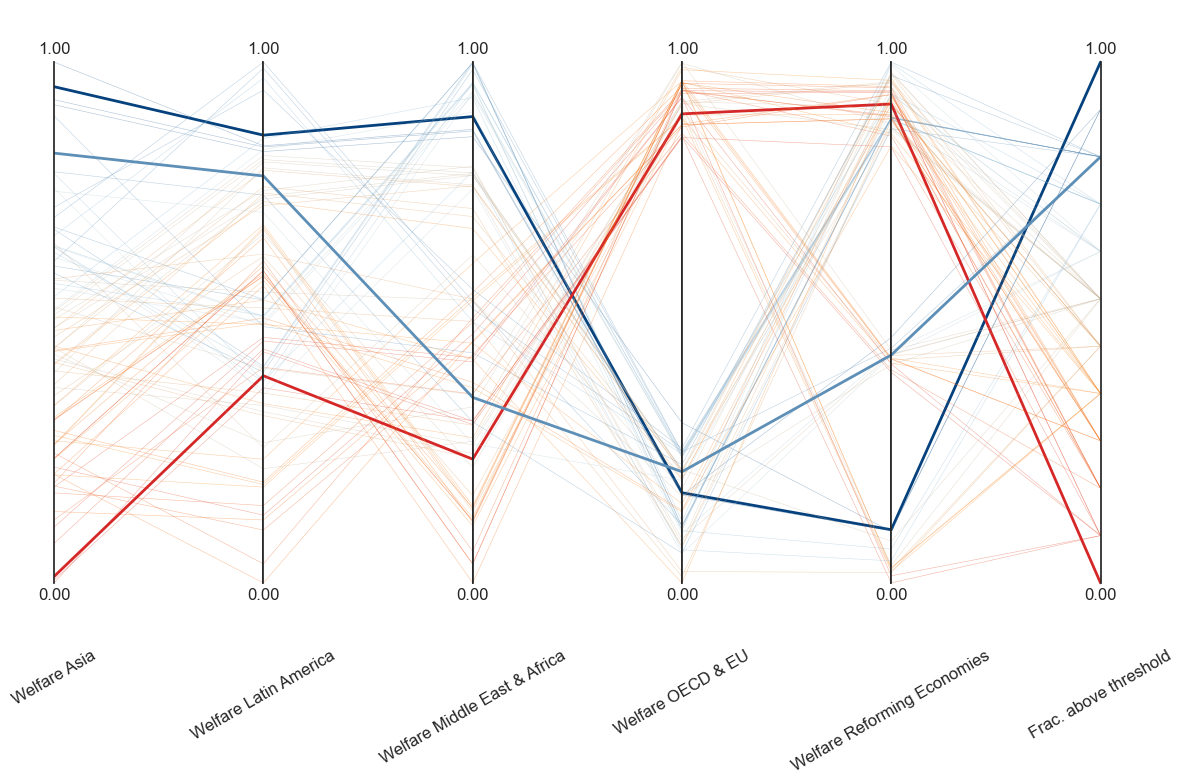

In [ ]:
# ── Section 5b: Pareto-Nash Tradeoff Visualization (Parallel Coordinates) ────
from justice.util.visualizer import visualize_tradeoffs_colored

# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path      = "data/temporary/MOMA_DATA/200k"
processed_path = f"{base_path}/PROCESSED_DATA"
plots_dir      = f"{base_path}/plots"

# ── CONFIG ────────────────────────────────────────────────────────────────────
filename = "pareto_nash_profiles.csv"

list_of_objectives = [
    "welfare_0",
    "welfare_1",
    "welfare_2",
    "welfare_3",
    "welfare_4",
    "fraction_above_threshold",
]

direction_of_optimization = ["max", "max", "max", "max", "max", "min"]

pretty_labels = [
    "Welfare Asia",                    # welfare_0 → R5ASIA
    "Welfare Latin America",           # welfare_1 → R5LAM
    "Welfare Middle East & Africa",    # welfare_2 → R5MAF
    "Welfare OECD & EU",               # welfare_3 → R5OECD
    "Welfare Reforming Economies",     # welfare_4 → R5REF
    "Frac. above threshold",
]

# Focal profiles: best temperature, worst temperature, joint candidate 
focal_indices = [9, 52, 86]

# ── PLOT ──────────────────────────────────────────────────────────────────────
concatenated_df = visualize_tradeoffs_colored(
    input_data                = [filename],
    figsize                   = (12, 8),
    set_style                 = "whitegrid",
    font_scale                = 1.8,
    colourmap                 = "bright",
    linewidth                 = 0.4,
    alpha                     = 0.4,
    path_to_data              = processed_path,
    path_to_output            = plots_dir,
    scaling                   = True,
    feature_range             = (0, 1),
    column_labels             = None,
    legend_labels             = None,
    show_legend               = False,
    axis_rotation             = 30,
    fontsize                  = 12,
    list_of_objectives        = list_of_objectives,
    direction_of_optimization = direction_of_optimization,
    pretty_labels             = pretty_labels,
    default_colors            = ["red", "blue"],
    top_percentage            = 0.1,
    show_best_solutions       = True,
    highlight_indices         = {filename: focal_indices},
    highlight_factor          = 5,
    objective_of_interest     = "fraction_above_threshold",
    saving                    = False,
)

### 5c Clustered Curved Parallel Coordinates Plot

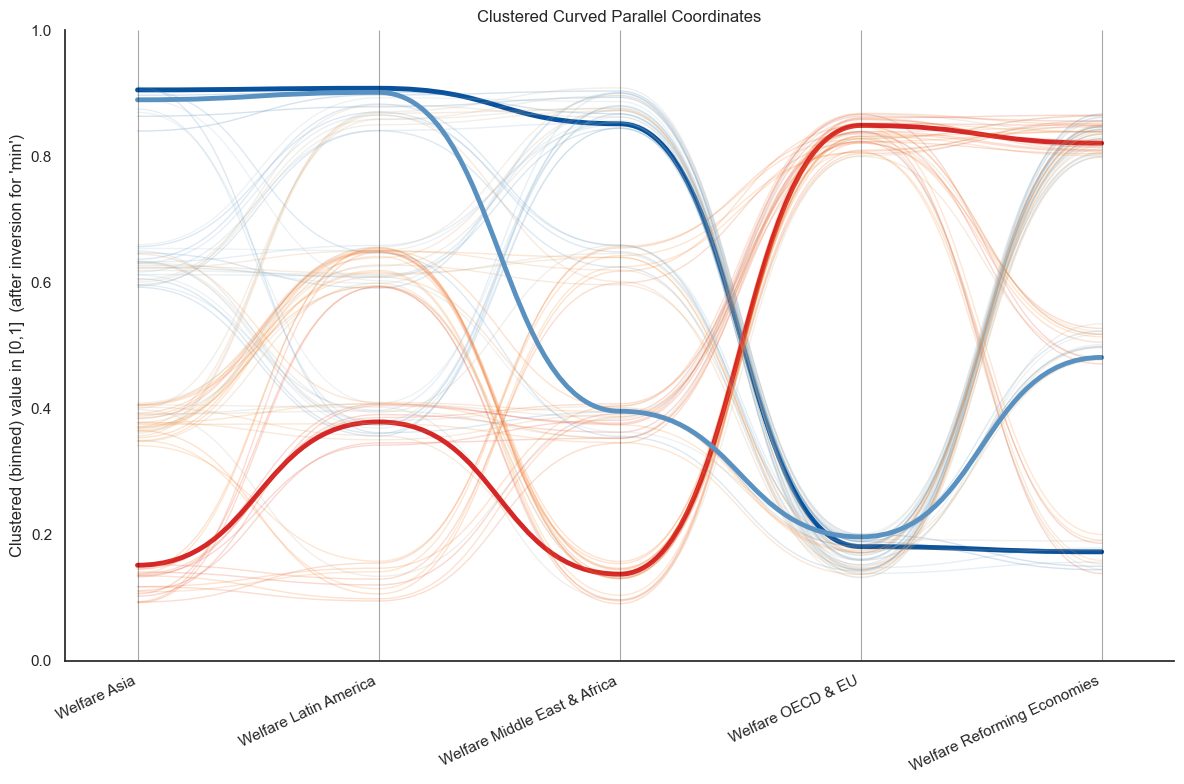

Plot saved: data/temporary/MOMA_DATA/200k/plots/clustered_parallel_coordinates.svg


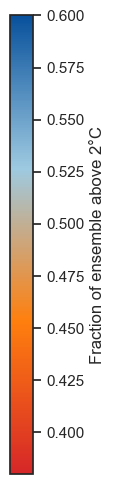

Colorbar saved: data/temporary/MOMA_DATA/200k/plots/colorbar_fraction_above_threshold.svg


/var/folders/l1/cbpvtb4x2c38sfgzlzdply84c5jfvg/T/ipykernel_43850/803830913.py:94: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

/var/folders/l1/cbpvtb4x2c38sfgzlzdply84c5jfvg/T/ipykernel_43850/803830913.py:95: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [3]:
# ── Section 5c: Clustered Curved Parallel Coordinates (Paper Figure) ─────────
from justice.util.visualizer import curved_parallel_coordinates_clustered, plot_colorbar_standalone
import pandas as pd
import os

# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path      = "data/temporary/MOMA_DATA/200k"
processed_path = f"{base_path}/PROCESSED_DATA"
plots_dir      = f"{base_path}/plots"
os.makedirs(plots_dir, exist_ok=True)

# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_csv(f"{processed_path}/pareto_nash_profiles.csv")

# ── CONFIG ────────────────────────────────────────────────────────────────────
objectives = [
    "welfare_0",
    "welfare_1",
    "welfare_2",
    "welfare_3",
    "welfare_4",
    "fraction_above_threshold",
]
directions = ["max", "max", "max", "max", "max", "min"]

# Temperature axis hidden from plot but still used for colouring
columns_to_plot = [
    "welfare_0",
    "welfare_1",
    "welfare_2",
    "welfare_3",
    "welfare_4",
]

pretty_labels = [
    "Welfare Asia",                    # welfare_0 → R5ASIA
    "Welfare Latin America",           # welfare_1 → R5LAM
    "Welfare Middle East & Africa",    # welfare_2 → R5MAF
    "Welfare OECD & EU",               # welfare_3 → R5OECD
    "Welfare Reforming Economies",     # welfare_4 → R5REF
]

# Focal profiles — 9: best temp, 52: worst temp, 86: compromise
highlight = [9, 52, 86]

# ── PLOT: Clustered Curved Parallel Coordinates ───────────────────────────────
df_scaled, df_clustered, fig, ax = curved_parallel_coordinates_clustered(
    df                        = df,
    objectives                = objectives,
    direction_of_optimization = directions,
    color_by                  = "fraction_above_threshold",
    columns_to_plot           = columns_to_plot,
    labels                    = pretty_labels,
    bins                      = {
        "welfare_0": 4,
        "welfare_1": 4,
        "welfare_2": 4,
        "welfare_3": 3,
        "welfare_4": 3,
        "default":   3,
    },
    jitter           = 0.035,
    alpha            = 0.20,
    linewidth        = 1.0,
    curvature        = 0.5,
    highlight_indices = highlight,
    highlight_factor  = 3.5,
    highlight_alpha   = 1.0,
    title             = "Clustered Curved Parallel Coordinates",
)

fig.savefig(
    f"{plots_dir}/clustered_parallel_coordinates.svg",
    format="svg", bbox_inches="tight"
)
print(f"Plot saved: {plots_dir}/clustered_parallel_coordinates.svg")

# ── LEGEND: Standalone Colorbar ───────────────────────────────────────────────
fig_cb, cbar = plot_colorbar_standalone(
    df           = df,             # original df, not df_scaled
    color_by     = "fraction_above_threshold",
    custom_colors = ("#d62728", "#ff7f0e", "#9ecae1", "#08519c"),
    label        = "Fraction of ensemble above 2°C",
    orientation  = "vertical",
    figsize      = (1.2, 5),
)

fig_cb.savefig(
    f"{plots_dir}/colorbar_fraction_above_threshold.svg",
    format="svg", bbox_inches="tight"
)
print(f"Colorbar saved: {plots_dir}/colorbar_fraction_above_threshold.svg")

fig.show()
fig_cb.show()

### 5d. Simulate & Save Pareto-Nash Profiles' model outputs for visualization

In [1]:
# ── Section 5d: Simulate & Save Focal Pareto-Nash Profiles ───────────────────
from justice.util.pareto_nash_simulate import simulate_nash_profiles_by_row_index

# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path         = "data/temporary/MOMA_DATA/200k"
processed_path    = f"{base_path}/PROCESSED_DATA"
model_output_path = f"{processed_path}/model_outputs"

nash_profiles_csv = f"{processed_path}/pareto_nash_profiles.csv"
policy_5row_csv   = f"{base_path}/COMBINED_MOMA_epsilon_nondominated_set.csv"
config_path       = "analysis/momadps_config.json"
mapping_base      = "data/input"

# Focal profiles — 9: best temp, 52: worst temp, 86: compromise
focal_indices = [9, 52, 86]

# ── SIMULATE & SAVE ───────────────────────────────────────────────────────────
simulate_nash_profiles_by_row_index(
    nash_profiles_csv        = nash_profiles_csv,
    policy_5row_csv          = policy_5row_csv,
    config_path              = config_path,
    out_dir                  = model_output_path,
    selected_profile_indices = focal_indices,
    scenario                 = 2,
    mapping_base_path        = mapping_base,
)

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nash profiles    : data/temporary/MOMA_DATA/200k/PROCESSED_DATA/pareto_nash_profiles.csv  (88 total)
Policy CSV       : data/temporary/MOMA_DATA/200k/COMBINED_MOMA_epsilon_nondominated_set.csv
Profiles to run  : [9, 52, 86]
Output dir       : data/temporary/MOMA_DATA/200k/PROCESSED_DATA/model_outputs
⚠ This may take several minutes per profile.

  Profile   9 | actions: (0, 1, 4, 3, 2) ... done  |  frac_above_2C: 0.380
  Profile  52 | actions: (3, 3, 3, 2, 0) ... done  |  frac_above_2C: 0.600
  Profile  86 | actions: (4, 4, 4, 4, 4) ... done  |  frac_above_2C: 0.420

All done. Files saved to: data/temporary/MOMA_DATA/200k/PROCESSED_DATA/model_outputs


### 5e: Global Temperature Visualization

In [ ]:
# ── Section 5e: Global Temperature Visualization ─────────────────────────────
from justice.util.visualizer import plot_comparison_with_boxplots
from pathlib import Path
import numpy as np
import os
from justice.util.pareto_nash_simulate import get_array_path, load_nash_profile


# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path         = "data/temporary/MOMA_DATA/200k"
processed_path    = f"{base_path}/PROCESSED_DATA"
model_output_path = f"{processed_path}/model_outputs"
plots_dir         = f"{base_path}/plots"
os.makedirs(plots_dir, exist_ok=True)

# ── HELPERS ───────────────────────────────────────────────────────────────────
DATASET_KEYS = [
    "constrained_emission_control_rate",
    "emissions",
    "economic_damage",
    "abatement_cost",
    "global_temperature",
    "net_economic_output",
    "gross_economic_output",
]

# Focal profiles — 9: best temp, 52: worst temp, 86: compromise
focal_indices = [9, 52, 86]

profile_data = {
    idx: load_nash_profile(model_output_path, idx, DATASET_KEYS)
    for idx in focal_indices
}

labels = {
    9:  "Best temperature",
    52: "Worst temperature",
    86: "Compromise",
}

# ── CONFIG ────────────────────────────────────────────────────────────────────
LINE_COLOR = "rgba(217, 175, 107, 1)"
FILL_COLOR = "rgba(217, 175, 107, 0.2)"

# ── PLOT — one figure per policy ──────────────────────────────────────────────
for policy_idx in focal_indices:
    fig = plot_comparison_with_boxplots(
        data_paths               = [get_array_path(model_output_path, policy_idx, "global_temperature")],
        labels                   = [labels[policy_idx]],
        start_year               = 2015,
        end_year                 = 2300,
        data_timestep            = 5,
        timestep                 = 1,
        visualization_start_year = 2025,
        visualization_end_year   = 2100,
        yaxis_range              = [0.5, 5],
        plot_title               = " ",
        xaxis_title              = "Year",
        yaxis_title              = "Global Temperature (°C)",
        template                 = "plotly_white",
        width                    = 1000,
        height                   = 700,
        output_path              = plots_dir,
        saving                   = False,
        show_red_dashed_line     = False,
        show_interquartile_range = True,
        linecolors               = [LINE_COLOR],
        colors                   = [FILL_COLOR],
        first_plot_proportion    = [0, 0.8],
        second_plot_proportion   = [0.90, 1],
        transpose_data           = True,
    )
    fig.show()

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5f: Regional Emissions Visualization

In [1]:
# ── Section 5f: Regional Emissions Visualization ──────────────────────────────
from justice.util.visualizer import plot_regional_emissions_comparison_with_boxplots
import json
from justice.util.pareto_nash_simulate import get_array_path, load_nash_profile

# ── CONFIG ────────────────────────────────────────────────────────────────────
base_path         = "data/temporary/MOMA_DATA/200k"
processed_path    = f"{base_path}/PROCESSED_DATA"
model_output_path = f"{processed_path}/model_outputs"
REGION_MAP_PATH  = "data/input/R5_regions.json"
BASELINE_PATH    = f"{model_output_path}/baseline_emissions_16.npy"
plots_dir         = f"{base_path}/plots"

# Focal profiles — 9: best temp, 52: worst temp, 86: compromise
focal_indices = [9, 52, 86]

with open(REGION_MAP_PATH, "r") as fh:
    region_dict = json.load(fh)

# ── REGION REGISTRY ───────────────────────────────────────────────────────────
REGIONS = [
    {"id": "R5ASIA", "label": "Asia",                  "fill": "rgba(252, 141,  98, 0.8)", "line": "rgba(252, 141,  98, 1)"},
    {"id": "R5LAM",  "label": "Latin America",         "fill": "rgba( 93, 105, 177, 0.8)", "line": "rgba( 93, 105, 177, 1)"},
    {"id": "R5MAF",  "label": "Middle East & Africa",  "fill": "rgba(218, 165,  27, 0.8)", "line": "rgba(218, 165,  27, 1)"},
    {"id": "R5OECD", "label": "OECD & EU",             "fill": "rgba( 47, 138, 196, 0.8)", "line": "rgba( 47, 138, 196, 1)"},
    {"id": "R5REF",  "label": "Reforming Economies",   "fill": "rgba(153, 201,  69, 0.8)", "line": "rgba(153, 201,  69, 1)"},
]

# ── PLOT — one figure per policy × region ─────────────────────────────────────
emission_figs = {}  # keyed by (policy_idx, region_id)

for policy_idx in focal_indices:
    for region in REGIONS:
        fig = plot_regional_emissions_comparison_with_boxplots(
            data_paths               = [get_array_path(model_output_path, policy_idx, "emissions")],
            start_year               = 2015,
            end_year                 = 2300,
            data_timestep            = 5,
            timestep                 = 1,
            visualization_start_year = 2024,
            visualization_end_year   = 2100,
            yaxis_range              = [0, 35],
            opacity                  = 0.001,
            plot_title               = f"{region['label']} Emissions",
            xaxis_title              = "Year",
            yaxis_title              = "Emissions",
            template                 = "plotly_white",
            width                    = 1000,
            height                   = 700,
            baseline_path            = BASELINE_PATH,
            region_dict              = region_dict,
            region_aggregation       = True,
            region_name              = region["id"],
            colors                   = [region["fill"]],
            median_colors            = [region["line"]],
            saving                   = True,
            output_path              = plots_dir,
            output_filename          = f"policy_{policy_idx}_{region['label'].replace(' ', '_').replace('&', 'and')}_emissions",
        )
        emission_figs[(policy_idx, region["id"])] = fig
        fig.show()

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5g. Plot Abatement Costs and Damage costs as a percentage of gross economic output

In [3]:
# ── Section 5g: Abatement Costs and Damage costs as a percentage of gross economic output ──────────────────────────────
from justice.util.visualizer import plot_abatement_damage_costs

# ── CONFIG ────────────────────────────────────────────────────────────────────
CONFIG_PATH       = "analysis/momadps_config.json"
MAPPING_BASE_PATH = "data/input"
base_path         = "data/temporary/MOMA_DATA/200k"
processed_path    = f"{base_path}/PROCESSED_DATA"
model_output_path = f"{processed_path}/model_outputs"
REGION_MAP_PATH  = "data/input/R5_regions.json"
BASELINE_PATH    = f"{model_output_path}/baseline_emissions_16.npy"
plots_dir         = f"{base_path}/plots"

# Focal profiles — 9: best temp, 52: worst temp, 86: compromise
focal_indices = [9, 52, 86]

# ── STYLE ─────────────────────────────────────────────────────────────────────
ECON_STYLE = dict(
    color_abatement              = "#46b6fb",
    color_damage                 = "#e9820c",
    band_alpha                   = 0.20,
    median_linewidth             = 2.0,
    visualization_start_year     = 2015,
    visualization_end_year       = 2300,
    uncertainty_lower_percentile = 0.0,
    uncertainty_upper_percentile = 100.0,
    yaxis_lower_limit            = 0.0,
    yaxis_upper_limit            = 25.0,
)

# ── PLOT — one figure per policy ──────────────────────────────────────────────
economic_figs = {}  # keyed by policy_idx

for policy_idx in focal_indices:
    fig = plot_abatement_damage_costs(
        profile_indices   = [policy_idx],
        data_dir          = model_output_path,
        output_path       = plots_dir,
        config_path       = CONFIG_PATH,
        mapping_base_path = MAPPING_BASE_PATH,
        saving            = True,
        **ECON_STYLE,
    )
    economic_figs[policy_idx] = fig

VERIFICATION: net + damage + abatement ≈ gross
  Profile   9: max_rel_err=2.22e-16  ✓ PASS

Saved: cost_share_profile9_R5ASIA.svg
Saved: cost_share_profile9_R5LAM.svg
Saved: cost_share_profile9_R5MAF.svg
Saved: cost_share_profile9_R5OECD.svg
Saved: cost_share_profile9_R5REF.svg
VERIFICATION: net + damage + abatement ≈ gross
  Profile  52: max_rel_err=2.24e-16  ✓ PASS

Saved: cost_share_profile52_R5ASIA.svg
Saved: cost_share_profile52_R5LAM.svg
Saved: cost_share_profile52_R5MAF.svg
Saved: cost_share_profile52_R5OECD.svg
Saved: cost_share_profile52_R5REF.svg
VERIFICATION: net + damage + abatement ≈ gross
  Profile  86: max_rel_err=2.23e-16  ✓ PASS

Saved: cost_share_profile86_R5ASIA.svg
Saved: cost_share_profile86_R5LAM.svg
Saved: cost_share_profile86_R5MAF.svg
Saved: cost_share_profile86_R5OECD.svg
Saved: cost_share_profile86_R5REF.svg


### 5h. RBF Hyperparameter Visualization

In [1]:
# ── Section 5h: RBF Hyperparameter Visualization ──────────────────────────────
from justice.util.visualizer import visualize_rbf_hyperparameters
import os

# Focal profiles — 9: best temp, 52: worst temp, 86: compromise
focal_indices = [9, 52, 86]


labels = {
    9:  "Best temperature",
    52: "Worst temperature",
    86: "Compromise",
}

# ── PATHS ─────────────────────────────────────────────────────────────────────
base_path         = "data/temporary/MOMA_DATA/200k"
processed_path    = f"{base_path}/PROCESSED_DATA"
model_output_path = f"{processed_path}/model_outputs"
joint_path        = f"{base_path}/JOINT_OPTIMIZATION"
plots_dir         = f"{base_path}/plots"
os.makedirs(plots_dir, exist_ok=True)

# ── FILES ─────────────────────────────────────────────────────────────────────
input_file  = f"{joint_path}/COMBINED_MOMA_epsilon_nondominated_set.csv"
output_file = f"{processed_path}/pareto_nash_profiles.csv"


# ── CONFIG ────────────────────────────────────────────────────────────────────
N_AGENTS     = 5
RBF_REF_PATH = f"{base_path}/MOMA_combined_reference_set_9_islands.csv"  # ← separate from input_file


# ── STYLE ─────────────────────────────────────────────────────────────────────
RBF_STYLE = dict(
    colorscale         = "plasma",
    outline_gap        = 1.5,
    saving             = True,
    output_path        = plots_dir,
    plot_saving_format = "svg",
    show               = True,
)


# ── PLOT — one figure per policy × agent ──────────────────────────────────────
rbf_figs = {}  # keyed by (policy_idx, agent_id)

for policy_idx in focal_indices:
    for agent_id in range(N_AGENTS):
        fig = visualize_rbf_hyperparameters(
            filepath        = RBF_REF_PATH,
            agent           = agent_id,
            row_index       = policy_idx,
            fig_title       = f"{labels[policy_idx]} — Agent {agent_id} RBF parameters",
            output_filename = f"policy_{policy_idx}_agent{agent_id}_rbf",
            **RBF_STYLE,
        )
        rbf_figs[(policy_idx, agent_id)] = fig